In [1]:
import numpy as np
import os, tqdm, h5py
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import corner
import tools21cm as t2c

In [2]:
output_stat_dir = '../output'

In [3]:
# Astro params
params = ['ION_Tvir_MIN','R_BUBBLE_MAX','HII_EFF_FACTOR']
# Fisher_Param = ['$T_{Vir}$','$R_{Max}$','$\zeta$']
Fisher_Param = [r'$T_{Vir}~[10^4 \mathrm{K}]$', r'$R_{Max}$', r'$\zeta$']
nparams = len(params)
# parameter values for fiducial simulation
fid = np.array([10**4.7,15,30])

In [4]:
model_files = {}

model_files['PS 1D'] = {
    'AA* (100 h)' : os.path.join(output_stat_dir, f'posterior_covariance_matrix_AAstar_100hours_ps.txt'),
    'AA* (1000 h)': os.path.join(output_stat_dir, f'posterior_covariance_matrix_AAstar_1000hours_ps.txt'),
    'AA4 (1000 h)': os.path.join(output_stat_dir, f'posterior_covariance_matrix_AA4_1000hours_ps.txt'),
}

model_files['PS 2D'] = {
    'AA* (100 h)' : os.path.join(output_stat_dir, f'posterior_covariance_matrix_AAstar_100hours_PS2D_no_wedge_updated.txt'),
    'AA* (1000 h)': os.path.join(output_stat_dir, f'posterior_covariance_matrix_AAstar_1000hours_PS2D_no_wedge_updated.txt'),
    'AA4 (1000 h)': os.path.join(output_stat_dir, f'posterior_covariance_matrix_AA4_1000hours_PS2D_no_wedge_updated.txt'),
}

model_files['MAPS'] = {
    # 'AA* (100 h)' : os.path.join(output_stat_dir, f'posterior_covariance_matrix_AAstar_100hours_MAPS.txt'),
    # 'AA* (1000 h)': os.path.join(output_stat_dir, f'posterior_covariance_matrix_AAstar_1000hours_MAPS.txt'),
    # 'AA4 (1000 h)': os.path.join(output_stat_dir, f'posterior_covariance_matrix_AA4_1000hours_MAPS.txt'),
    'AA* (100 h)' : os.path.join(output_stat_dir, f'posterior_covariance_matrix_AAstar_100hours_MAPS_diag.txt'),
    'AA* (1000 h)': os.path.join(output_stat_dir, f'posterior_covariance_matrix_AAstar_1000hours_MAPS_diag.txt'),
    'AA4 (1000 h)': os.path.join(output_stat_dir, f'posterior_covariance_matrix_AA4_1000hours_MAPS_diag.txt'),
}

--- PS 1D ---
AA* (100 h): [  2.5938231  -74.5192659   11.75425789], [  7.86205303 108.62761713  48.66090811]
AA* (1000 h): [  4.03373589 -19.7906376   25.62732843], [ 6.1638125  50.2617383  35.09036253]
AA4 (1000 h): [ 4.39224129 -7.06179758 27.92067068], [ 5.45282649 29.58234205 31.77784023]


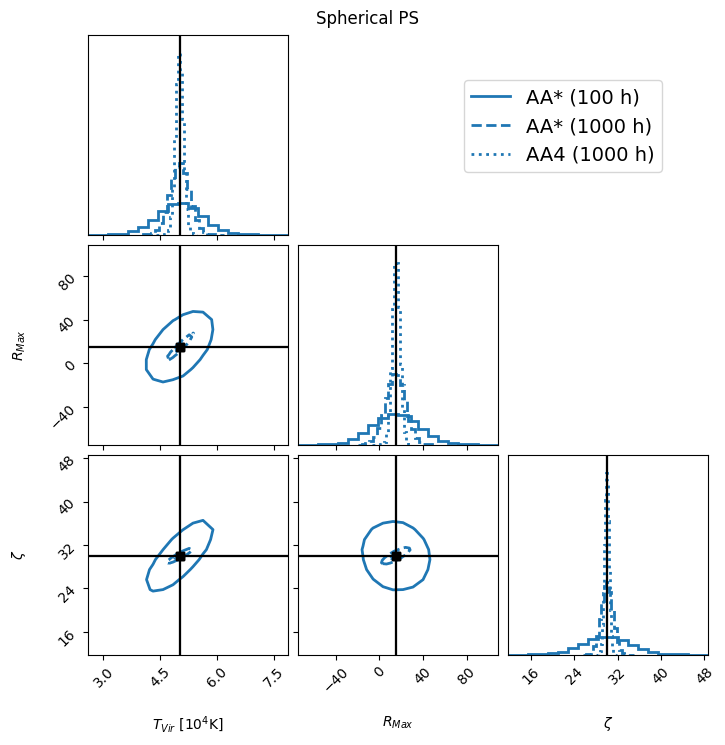

--- PS 2D ---
AA* (100 h): [-24.33541825 -98.05484511 -78.68836167], [ 36.56168227 117.03534559 138.30099216]
AA* (1000 h): [ -0.11161139 -54.16876868   1.42858307], [10.44448675 81.4548856  59.07863092]
AA4 (1000 h): [  0.05296688 -50.57128011   2.77457251], [ 9.92192826 72.60274471 55.20388468]


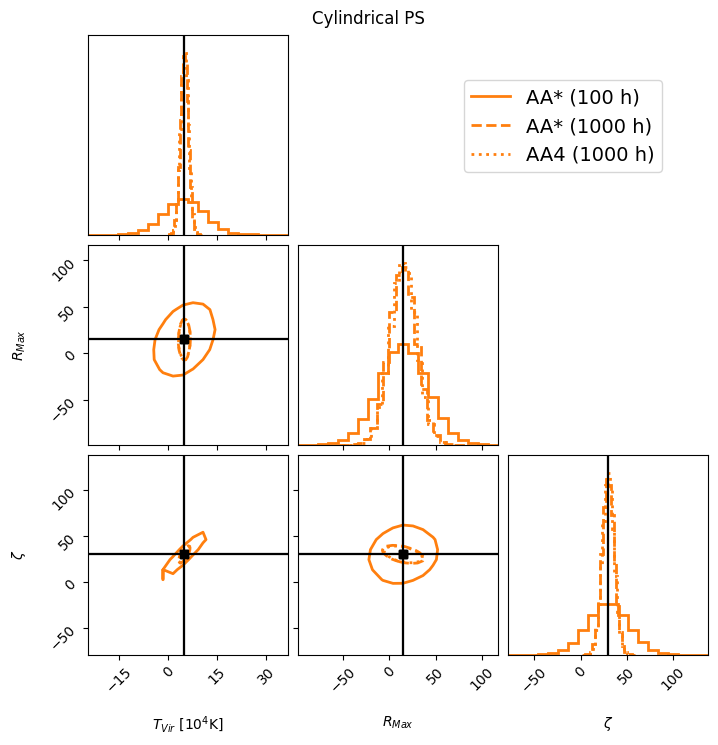

--- MAPS ---
AA* (100 h): [  1.6098863  -63.59322997   1.16617194], [ 8.61261157 81.79071056 55.22689618]
AA* (1000 h): [  3.88838384 -10.51465933  18.84813445], [ 6.15710768 39.99187924 41.20884017]
AA4 (1000 h): [ 4.92543643 13.62458641 29.19039072], [ 5.10349132 16.64351266 30.78922895]


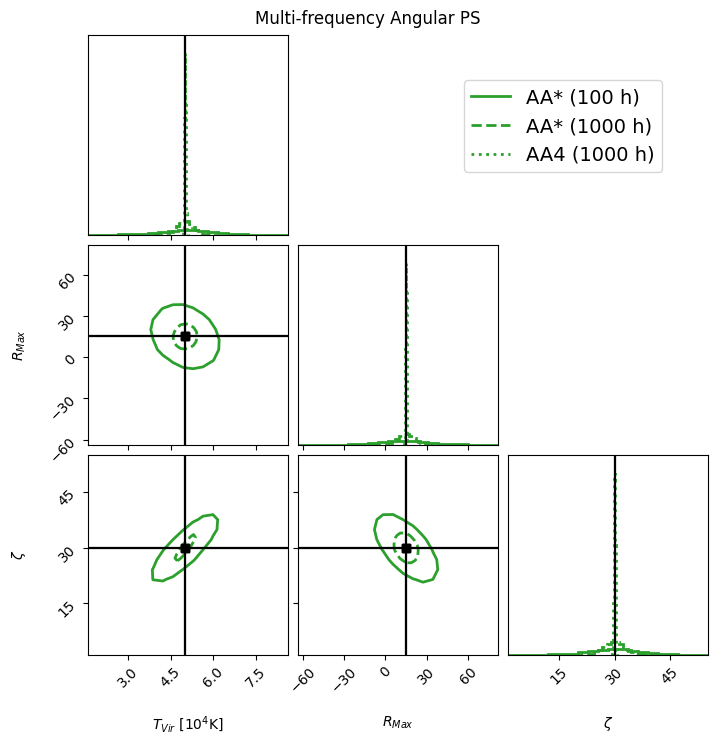

In [10]:
# --- Styling Definitions ---
# Define colors for each model type and linestyles for each case
style_guide = {
    'PS 1D': {'color': 'C0', 'label': 'Spherical PS'},
    'PS 2D': {'color': 'C1', 'label': 'Cylindrical PS'},
    'MAPS' : {'color': 'C2', 'label': 'Multi-frequency Angular PS'},
}

linestyles = {
    'AA* (100 h)' : ('-', 'AA* (100 h)'),
    'AA* (1000 h)': ('--', 'AA* (1000 h)'),
    'AA4 (1000 h)': (':', 'AA4 (1000 h)')
}

# --- Plotting ---
n_samples = 100000

truths = fid.copy()
truths[0] /= 1e4

levels = (0.675,) #(1-sigma, )
# levels = (0.864,) #(2-sigma, )
# levels = (0.675, 0.864) #(1-sigma, 2-sigma)

plot_cases = ['AA* (100 h)', 'AA* (1000 h)', 'AA4 (1000 h)']
# plot_cases = ['AA* (1000 h)', 'AA4 (1000 h)']

ranges = None

for model_type, cases in model_files.items():
    fig = None
    color = style_guide[model_type]['color']
    # Loop through the different observation cases
    print(f"--- {model_type} ---")
    for case_name, file_path in cases.items():
        if case_name in plot_cases:
            linestyle = linestyles[case_name][0]
            
            # Load covariance and generate samples
            cov = np.loadtxt(file_path)
            fisher_samples = np.random.multivariate_normal(fid, cov, size=n_samples)
            fisher_samples[:,0] /= 1e4
            print(f"{case_name}: {fisher_samples.min(axis=0)}, {fisher_samples.max(axis=0)}")
            
            # Add samples to the corner plot with specified styles
            fig = corner.corner(
                fisher_samples,
                fig=fig,
                labels=Fisher_Param,
                plot_datapoints=False,
                plot_density=False,
                levels=levels,
                truths=truths,
                truth_color='black',
                color=color, # Base color for the group
                # Apply linestyles to both 1D histograms and 2D contours
                hist_kwargs={'linestyle': linestyle, 'lw': 2, 'density': True},
                contour_kwargs={'linestyles': linestyle, 'linewidths': 2},
                range=ranges,
            )

    # --- Create Custom Legend ---
    # Create proxy artists for the legend
    legend_elements = []

    fig.suptitle(f"{style_guide[model_type]['label']}")
        
    # Add entries for observation cases (linestyles)
    for case_name, (ls, label) in linestyles.items():
        if case_name in plot_cases:
            legend_elements.append(mlines.Line2D(
                [], [], color=color, lw=2, linestyle=ls, label=label
            ))

    # Add the legend to the top-right corner of the figure
    fig.legend(handles=legend_elements, loc='upper right', fontsize=14, bbox_to_anchor=(0.90, 0.90))

    plt.show()

--- PS 1D ---
AA* (100 h): [  2.80374403 -83.38470501  10.43730927], [  7.38852248 115.01925469  48.40486193]
AA* (1000 h): [  3.94510296 -23.88498701  25.73818704], [ 6.19721247 54.08288769 34.8106994 ]
AA4 (1000 h): [ 4.58099926  1.37001021 27.99413532], [ 5.43695303 29.65349135 31.88266986]


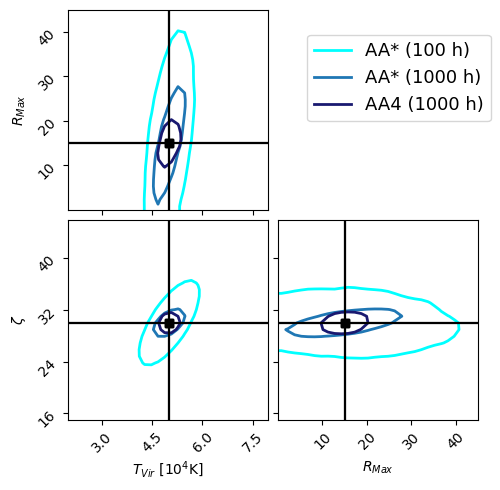

--- PS 1D ---
AA* (1000 h): [  3.81594427 -24.94352056  25.38513387], [ 6.08462933 51.59095914 34.28922694]
--- PS 2D ---
AA* (1000 h): [-1.76886515e-03 -4.66512334e+01  3.12089881e+00], [10.93593741 79.33158932 58.15596577]
--- MAPS ---
AA* (1000 h): [  3.85922824 -11.37971569  18.34815356], [ 6.22499689 41.139918   42.84139372]


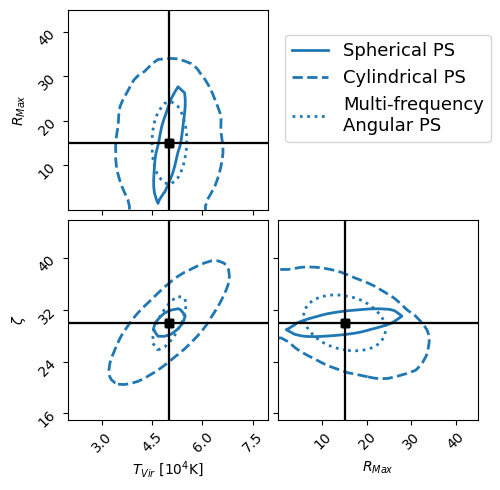

In [12]:
# --- Styling Definitions ---
# Define colors for each model type and linestyles for each case
style_guide = {
    'PS 1D': {'color': 'C0', 'ls': '-', 'label': 'Spherical PS'},
    'PS 2D': {'color': 'C1', 'ls': '--', 'label': 'Cylindrical PS'},
    'MAPS' : {'color': 'C2', 'ls': ':', 'label': 'Multi-frequency\nAngular PS'},
    'AA* (100 h)' : {'color': 'cyan', 'ls': '-', 'label': 'AA* (100 h)'},
    'AA* (1000 h)': {'color': 'C0', 'ls': '-', 'label': 'AA* (1000 h)'},
    'AA4 (1000 h)': {'color': 'midnightblue', 'ls': '-', 'label': 'AA4 (1000 h)'},
}

# --- Plotting ---
n_samples = 100000
remove_hist1d = True

truths = fid.copy()
truths[0] /= 1e4

levels = (0.675,) #(1-sigma, )
# levels = (0.864,) #(2-sigma, )
# levels = (0.675, 0.864) #(1-sigma, 2-sigma)

bins = 30
smooth = 1.0
smooth1d = None #2.0
labelpad = -0.1

ranges = [(2.0,7.95),(0,45),(15,46)]

plot_model = ['PS 1D']
plot_cases = ['AA* (100 h)', 'AA* (1000 h)', 'AA4 (1000 h)']

for model_type, cases in model_files.items():
    if model_type not in plot_model:
        continue
    fig = None
    legend_elements = []
    # Loop through the different observation cases
    print(f"--- {model_type} ---")
    for case_name, file_path in cases.items():
        if case_name in plot_cases:
            linestyle = style_guide[model_type]['ls']
            color = style_guide[case_name]['color']
            
            # Load covariance and generate samples
            cov = np.loadtxt(file_path)
            fisher_samples = np.random.multivariate_normal(fid, cov, size=n_samples)
            fisher_samples[:,0] /= 1e4
            print(f"{case_name}: {fisher_samples.min(axis=0)}, {fisher_samples.max(axis=0)}")
            
            # Add samples to the corner plot with specified styles
            fig = corner.corner(
                fisher_samples,
                bins=bins,
                fig=fig,
                labels=Fisher_Param,
                plot_datapoints=False,
                plot_density=False,
                levels=levels,
                truths=truths,
                truth_color='black',
                color=color, # Base color for the group
                # Apply linestyles to both 1D histograms and 2D contours
                hist_kwargs={'linestyle': linestyle, 'lw': 2, 'density': True},
                contour_kwargs={'linestyles': linestyle, 'linewidths': 2},
                range=ranges,
                smooth=smooth,
                smooth1d=smooth1d,
                labelpad=labelpad,
            )

            # --- Create Custom Legend ---
            legend_elements.append(mlines.Line2D(
                [], [], color=color, lw=2, linestyle=linestyle, label=style_guide[case_name]['label']
            ))

    if remove_hist1d:
        # === REMOVE UNUSED AXES ===
        ndim = len(Fisher_Param)
        axes = np.array(fig.axes).reshape((ndim, ndim))
        for i in range(ndim):
            for j in range(ndim):
                if i <= j:
                    fig.delaxes(axes[i, j])  # remove diagonal + upper triangle
        # Add the legend to the top-right corner of the figure
        fig.legend(handles=legend_elements, loc='upper right', fontsize=13, bbox_to_anchor=(0.70, 0.65))
    else:
        # Add the legend to the top-right corner of the figure
        fig.legend(handles=legend_elements, loc='upper right', fontsize=13, bbox_to_anchor=(0.90, 0.90))

plt.savefig('../figures/PS1D_Corner_3scenarios.pdf',bbox_inches='tight')
plt.show()

ranges = [(2.0,7.95),(0,45),(15,46)]

plot_model = ['PS 1D', 'PS 2D', 'MAPS']
plot_cases = ['AA* (1000 h)']

fig = None
legend_elements = []
for model_type, cases in model_files.items():
    if model_type not in plot_model:
        continue
    # Loop through the different observation cases
    print(f"--- {model_type} ---")
    count = 0
    for case_name, file_path in cases.items():
        if case_name in plot_cases:
            linestyle = style_guide[model_type]['ls']
            color = style_guide[case_name]['color']
            
            # Load covariance and generate samples
            cov = np.loadtxt(file_path)
            fisher_samples = np.random.multivariate_normal(fid, cov, size=n_samples)
            fisher_samples[:,0] /= 1e4
            print(f"{case_name}: {fisher_samples.min(axis=0)}, {fisher_samples.max(axis=0)}")
            
            # Add samples to the corner plot with specified styles
            fig = corner.corner(
                fisher_samples,
                bins=bins,
                fig=fig,
                labels=Fisher_Param,
                plot_datapoints=False,
                plot_density=False,
                levels=levels,
                truths=truths,
                truth_color='black',
                color=color, # Base color for the group
                # Apply linestyles to both 1D histograms and 2D contours
                hist_kwargs={'linestyle': linestyle, 'lw': 2, 'density': True},
                contour_kwargs={'linestyles': linestyle, 'linewidths': 2},
                range=ranges,
                smooth=smooth,
                smooth1d=smooth1d,
                labelpad=labelpad,
            )
            if count==0:
                # --- Create Custom Legend ---
                legend_elements.append(mlines.Line2D(
                    [], [], color=color, lw=2, linestyle=linestyle, label=style_guide[model_type]['label']
                ))
            count += 1

if remove_hist1d:
    # === REMOVE UNUSED AXES ===
    ndim = len(Fisher_Param)
    axes = np.array(fig.axes).reshape((ndim, ndim))
    for i in range(ndim):
        for j in range(ndim):
            if i <= j:
                fig.delaxes(axes[i, j])  # remove diagonal + upper triangle
    # Add the legend to the top-right corner of the figure
    fig.legend(handles=legend_elements, loc='upper right', fontsize=13, bbox_to_anchor=(0.70, 0.65))
else:
    # Add the legend to the top-right corner of the figure
    fig.legend(handles=legend_elements, loc='upper right', fontsize=13, bbox_to_anchor=(0.90, 0.90))
plt.savefig('../figures/PS1D_PS2D_MAPS_Corner.pdf',bbox_inches='tight')
plt.show()

## Power Spectrum Plots

In [7]:
ps_dir = '../PS_1D/SKA_chapter_statistics'

In [8]:
ps_files_FID = {
    'AA* (100 h)' : os.path.join(ps_dir, 'ps_FID_400_Samples_AAstar_100h.h5'),
    'AA* (1000 h)': os.path.join(ps_dir, 'ps_FID_400_Samples_AAstar_1000h.h5'),
    'AA4 (1000 h)': os.path.join(ps_dir, 'ps_FID_400_Samples_AA4_1000h.h5'),
}

ps_data_FID = {}
for case_name, fname in tqdm.tqdm(ps_files_FID.items()):
    with h5py.File(fname, 'r') as f:
        ps_data_FID[case_name] = {
            'clean': np.array(f['clean']),
            'noise': np.array(f['noise']),
            'obs'  : np.array(f['obs']),
            'bins' : np.array(f['bins'])
            }

  0%|          | 0/3 [00:00<?, ?it/s]

100%|██████████| 3/3 [00:00<00:00, 150.14it/s]


In [9]:
ps_files_Tvir_Plus = {
    'AA* (100 h)' : os.path.join(ps_dir, 'ps_ION_Tvir_MIN_400_Samples_Plus_AAstar_100h.h5'),
    'AA* (1000 h)': os.path.join(ps_dir, 'ps_ION_Tvir_MIN_400_Samples_Plus_AAstar_1000h.h5'),
    'AA4 (1000 h)': os.path.join(ps_dir, 'ps_ION_Tvir_MIN_400_Samples_Plus_AA4_1000h.h5'),
}

ps_data_Tvir_Plus = {}
for case_name, fname in tqdm.tqdm(ps_files_Tvir_Plus.items()):
    with h5py.File(fname, 'r') as f:
        ps_data_Tvir_Plus[case_name] = {
            'clean': np.array(f['clean']),
            'bins' : np.array(f['bins'])
            }
        
ps_files_Tvir_Minus = {
    'AA* (100 h)' : os.path.join(ps_dir, 'ps_ION_Tvir_MIN_400_Samples_Minus_AAstar_100h.h5'),
    'AA* (1000 h)': os.path.join(ps_dir, 'ps_ION_Tvir_MIN_400_Samples_Minus_AAstar_1000h.h5'),
    'AA4 (1000 h)': os.path.join(ps_dir, 'ps_ION_Tvir_MIN_400_Samples_Minus_AA4_1000h.h5'),
}

ps_data_Tvir_Minus = {}
for case_name, fname in tqdm.tqdm(ps_files_Tvir_Minus.items()):
    with h5py.File(fname, 'r') as f:
        ps_data_Tvir_Minus[case_name] = {
            'clean': np.array(f['clean']),
            'bins' : np.array(f['bins'])
            }

100%|██████████| 3/3 [00:00<00:00, 1068.07it/s]


In [14]:
ps_data_Tvir_Plus

{'AA* (100 h)': {'clean': array([[9.6926462e+05, 5.6441450e+05, 3.6268434e+05, ..., 1.5346053e+02,
          9.0256630e+01, 5.6638515e+01],
         [9.5126519e+05, 6.4729788e+05, 3.8401262e+05, ..., 1.5284015e+02,
          8.9770821e+01, 5.6666149e+01],
         [8.0212550e+05, 5.9426806e+05, 4.1301175e+05, ..., 1.5821445e+02,
          9.3166977e+01, 5.8902878e+01],
         ...,
         [1.6919896e+06, 8.6027800e+05, 4.3040475e+05, ..., 8.3776695e+01,
          3.8580029e+01, 2.4460503e+01],
         [3.3537031e+05, 4.5009253e+05, 2.4496323e+05, ..., 8.3535042e+01,
          3.7761925e+01, 2.3515297e+01],
         [8.4277931e+05, 8.3436406e+05, 4.0305378e+05, ..., 8.5120461e+01,
          3.9081451e+01, 2.4976696e+01]], shape=(400, 15), dtype=float32),
  'bins': array([0.05862373, 0.07971901, 0.10840525, 0.14741401, 0.20045976,
         0.2725936 , 0.37068423, 0.50407197, 0.68545823, 0.93211489,
         1.26752896, 1.7236391 , 2.34387682, 3.18730211, 4.33422724])},
 'AA* (1000 h)

3it [00:00, 409.33it/s]


Text(0, 0.5, '$\\frac{k^3}{2\\pi^2}P$ [mK$^2$]')

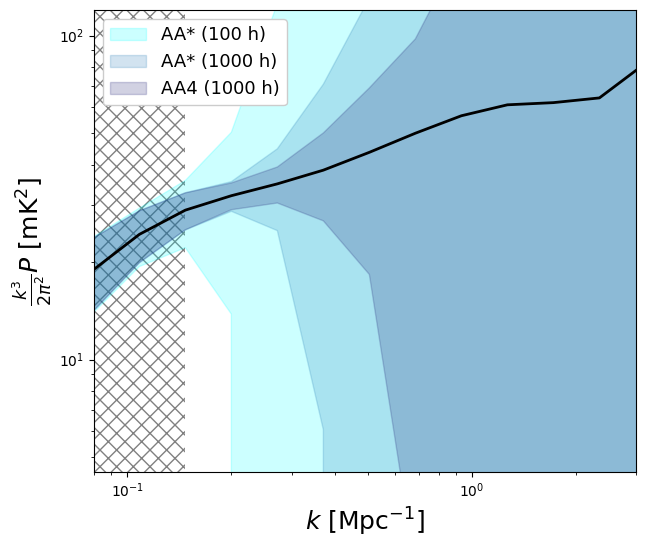

In [30]:
fig, ax = plt.subplots(1,1,figsize=(7,6))
case_name = 'AA4 (1000 h)'
ks, ps = ps_data_FID[case_name]['bins'], ps_data_FID[case_name]['clean'].mean(axis=0)
ax.loglog(ks, ps*ks**3/2/np.pi**2, color='black', lw=2)
plot_cases = ['AA* (100 h)', 'AA* (1000 h)', 'AA4 (1000 h)']
plot_color = ['cyan', 'C0', 'midnightblue']
for ii,case_name in tqdm.tqdm(enumerate(plot_cases)):
    std = np.sqrt(ps_data_FID[case_name]['noise'].std(axis=0)**2+ps_data_FID[case_name]['clean'].std(axis=0)**2)
    ax.fill_between(ks, (ps-std)*ks**3/2/np.pi**2, (ps+std)*ks**3/2/np.pi**2, alpha=0.2, color=plot_color[ii], label=case_name)
# case_name = 'AA4 (1000 h)'
# ks, ps = ps_data_Tvir_Plus[case_name]['bins'], ps_data_Tvir_Plus[case_name]['clean'].mean(axis=0)
# ax.loglog(ks, ps*ks**3/2/np.pi**2, color='black', lw=2, ls='--')
# case_name = 'AA4 (1000 h)'
# ks, ps = ps_data_Tvir_Minus[case_name]['bins'], ps_data_Tvir_Minus[case_name]['clean'].mean(axis=0)
# ax.loglog(ks, ps*ks**3/2/np.pi**2, color='black', lw=2, ls='-.')
mask = ks < 0.15 #1/Mpc (Pober+2014; Grieg & Mesinger 2015)
ax.fill_between(ks[mask], 1e-3, 1e4, color='none', hatch='xx', edgecolor='gray', linewidth=0.0, zorder=0)
ax.legend(loc=2, fontsize=13, facecolor='white', framealpha=1.0)
ax.axis([8e-2,3,4.5,1.2e2])
ax.set_xlabel('$k$ [Mpc$^{-1}$]', fontsize=18)
ax.set_ylabel(r'$\frac{k^3}{2\pi^2}P$ [mK$^2$]', fontsize=18)